In [1]:
import numpy as np
from scipy.stats.qmc import Sobol
import sys
import os
import matplotlib.pyplot as plt
from typing import Optional
import torch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from torch.quasirandom import SobolEngine
from botorch.acquisition import qLogExpectedImprovement, LogExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.models.transforms.outcome import Standardize
import math
from matplotlib.ticker import MultipleLocator

import pandas as pd
from IPython.display import display, HTML

sys.path.append(os.path.abspath(r"..\.."))
from model.PID import PID
from model.experiment_model import FirstPrincipleModel
from analysis import analysis

In [2]:
SAMPLE_NUM = 3
SEED = 4625

torch.manual_seed(SEED)

In [3]:
sampler = Sobol(d = 3, scramble=True, seed=SEED) # initial h1, initial h2, set point
sample = sampler.random_base2(m=SAMPLE_NUM)
print(sample)

[[8.40633426e-01 7.15120642e-01 2.69220616e-01]
 [1.39828773e-01 4.96616494e-03 5.95660023e-01]
 [2.71691271e-01 7.73619457e-01 1.57198651e-01]
 [6.93200960e-01 4.38915233e-01 9.55698204e-01]
 [5.73208007e-01 9.13314472e-01 6.25659749e-01]
 [3.99502967e-01 3.73438432e-01 4.87269658e-01]
 [5.41936606e-05 5.97033734e-01 8.00761406e-01]
 [9.56964262e-01 1.81646406e-01 6.40904661e-02]]


In [4]:
upper_bound = 8.5
lower_bound = 2.1

sample = (upper_bound - lower_bound)*sample + lower_bound
print(sample)

[[7.48005393 6.67677211 3.82301194]
 [2.99490415 2.13178346 5.91222415]
 [3.83882414 7.05116453 3.10607136]
 [6.53648614 4.90905749 8.21646851]
 [5.76853124 7.94521262 6.10422239]
 [4.65681899 4.49000596 5.21852581]
 [2.10034684 5.9210159  7.224873  ]
 [8.22457128 3.262537   2.51017898]]


In [5]:
DT = 5
T_HORIZON = 900
TOT_ITER = int(T_HORIZON/DT - 1)

In [6]:
def model_evaluation(kc: torch.Tensor, taui: Optional[torch.Tensor] = None, taud: Optional[torch.Tensor] = None):
    i_bool, d_bool = False, False
    
    if taui is not None:
        i_bool = True
    if taud is not None:
        d_bool = True    

    total_err = 0

    for i in range(2**SAMPLE_NUM):
        init_h1, init_h2, sp = sample[i]

        err = sp - init_h2
        err_traj = []
        err_traj.append(err)

        model = FirstPrincipleModel(init_h1, init_h2)
        controller = PID(kc=kc,
                        P=True, I=i_bool, D=d_bool,
                        u_min=0, u_max=36,
                        taui=taui, taud=taud
                        )
        mv = controller.final_control(sp, init_h2, DT)
        try:
            h1, h2 = model.step_pred(mv, init_h1, init_h2, DT)
        except RuntimeError as e:
            print(
                f"fail | kc={float(kc):.6f}, "
                f"taui={None if taui is None else float(taui):.6f}, "
                f"episode={i}, step={j}, sp={float(sp):.6f}, "
                f"h1={float(init_h1):.6f}, h2={float(init_h2):.6f}, mv={float(mv):.6f}"
            )
            raise

        err = sp - h2
        err_traj.append(err)

        for j in range(TOT_ITER):
            mv = controller.final_control(sp, h2, DT)
            try:
                h1, h2 = model.step_pred(mv, h1, h2, DT)
            except RuntimeError as e:
                print(
                    f"fail | kc={float(kc):.6f}, "
                    f"taui={None if taui is None else float(taui):.6f}, "
                    f"episode={i}, step={j}, sp={float(sp):.6f}, "
                    f"h1={float(h1):.6f}, h2={float(h2):.6f}, mv={float(mv):.6f}"
                )
                raise
            err = sp - h2
            err_traj.append(err)

        trajectories = model.outcome()
        
        iae = analysis(err_traj, trajectories["time"])[1][-1]
        total_err += iae
    
    total_err = total_err/(2**SAMPLE_NUM)
    return -total_err

In [7]:
P_MULTIPLE = 200

PRIORI_SAMPLE_SIZE = 16

## P Tuning

In [8]:
d = 1

sobol = SobolEngine(dimension=d, scramble=True)
train_X = sobol.draw(PRIORI_SAMPLE_SIZE).to(dtype=torch.float64)

train_Y = torch.tensor([[model_evaluation(P_MULTIPLE*x[0])] for x in train_X], dtype=torch.float64)

In [9]:
gp = SingleTaskGP(train_X = train_X,
                  train_Y = train_Y,
                  outcome_transform = Standardize(m=1))
mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
fit_gpytorch_mll(mll)
state_dict = gp.state_dict()
best_Y = train_Y.max().item()

In [10]:
NUM_BO_ITER = 150

best_output = []
best_output.append(best_Y)

bounds = torch.stack([torch.tensor([0]), torch.tensor([1])]).to(torch.double)

for i in range(NUM_BO_ITER):
    EI = qLogExpectedImprovement(model=gp, best_f=best_Y)

    candidate, acq_value = optimize_acqf(
        EI, bounds=bounds, q=1, num_restarts=10, raw_samples=64, options={"maxiter": 50}
    )
    if i%(NUM_BO_ITER/10) == 0:
        print(f"{int(i/NUM_BO_ITER*100)}%")
    candidate_Y = torch.tensor([[model_evaluation(P_MULTIPLE*candidate)]], dtype=torch.double)
    train_X, train_Y = torch.cat([train_X, candidate]), torch.cat([train_Y, candidate_Y])
    best_Y = train_Y.max().item()
    best_output.append(best_Y)
    gp = SingleTaskGP(train_X = train_X,
                    train_Y = train_Y,
                    outcome_transform = Standardize(m=1))
    gp.load_state_dict(state_dict, strict=False)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    state_dict = gp.state_dict()

0%


c:\Users\mccha\miniconda3\envs\three_tank_control\Lib\site-packages\botorch\optim\optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


10%
20%


c:\Users\mccha\miniconda3\envs\three_tank_control\Lib\site-packages\botorch\optim\optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


30%


c:\Users\mccha\miniconda3\envs\three_tank_control\Lib\site-packages\botorch\optim\optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


40%
50%
60%


c:\Users\mccha\miniconda3\envs\three_tank_control\Lib\site-packages\botorch\optim\optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


70%
80%
90%


c:\Users\mccha\miniconda3\envs\three_tank_control\Lib\site-packages\botorch\optim\optimize.py:796: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


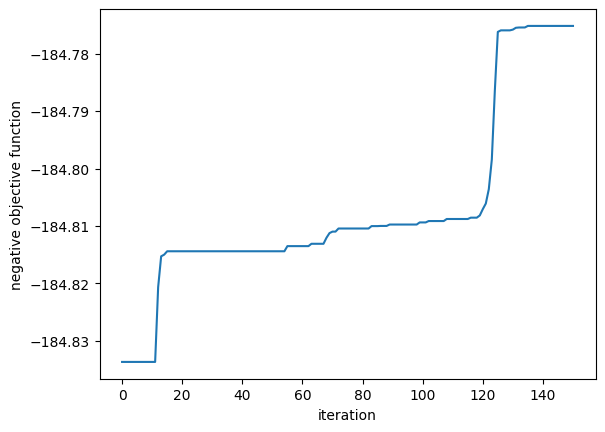

-184.77518045249087
36.70033343935836


In [11]:
plt.plot(best_output)
plt.xlabel("iteration")
plt.ylabel("negative objective function")
plt.show()

print(best_output[-1])

best_arg = torch.argmax(train_Y)
kc_opt = float(train_X[best_arg][0]*P_MULTIPLE)
print(kc_opt)

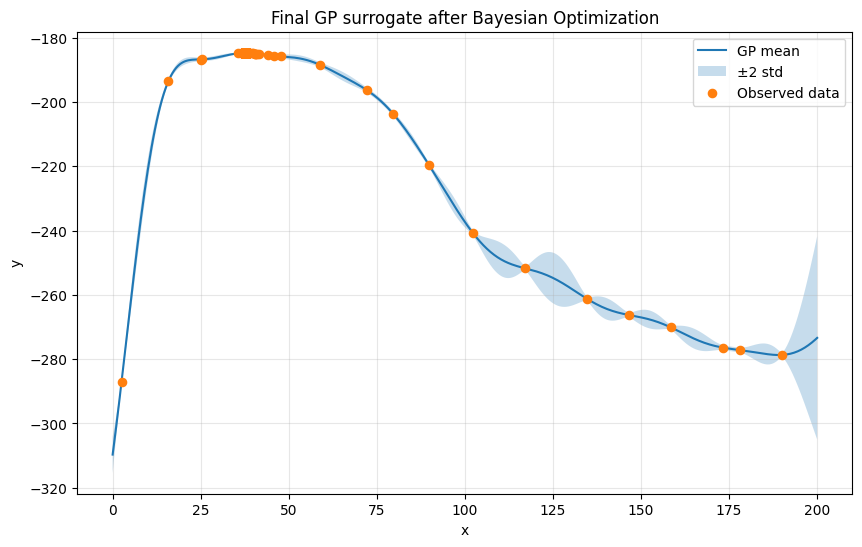

In [12]:
# final trained model after BO loop
gp.eval()
gp.likelihood.eval()

# dense grid over the normalized design space [0, 1]
x_plot = torch.linspace(0, 1, 400, dtype=torch.double).unsqueeze(-1)

with torch.no_grad():
    # latent-function posterior
    posterior = gp.posterior(x_plot)

    mean = posterior.mean.squeeze(-1).cpu()
    std = posterior.variance.sqrt().squeeze(-1).cpu()

# convert x-axis to original scale if your true evaluation used P_MULTIPLE * x
x_plot_orig = (P_MULTIPLE * x_plot).squeeze(-1).cpu()
train_X_orig = (P_MULTIPLE * train_X).squeeze(-1).cpu()
train_Y_cpu = train_Y.squeeze(-1).cpu()

plt.figure(figsize=(10, 6))

# GP mean
plt.plot(x_plot_orig.numpy(), mean.numpy(), label="GP mean")

# uncertainty band: mean ± 2 std (roughly 95%)
plt.fill_between(
    x_plot_orig.numpy(),
    (mean - 2 * std).numpy(),
    (mean + 2 * std).numpy(),
    alpha=0.25,
    label="±2 std"
)

# observed data
plt.scatter(train_X_orig.numpy(), train_Y_cpu.numpy(), s=35, label="Observed data", zorder=3)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Final GP surrogate after Bayesian Optimization")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

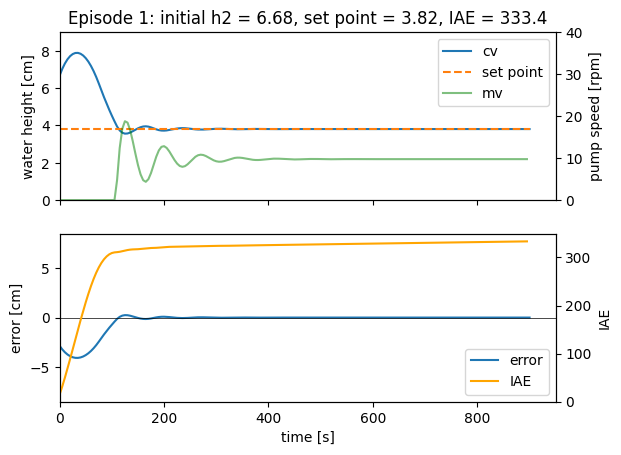

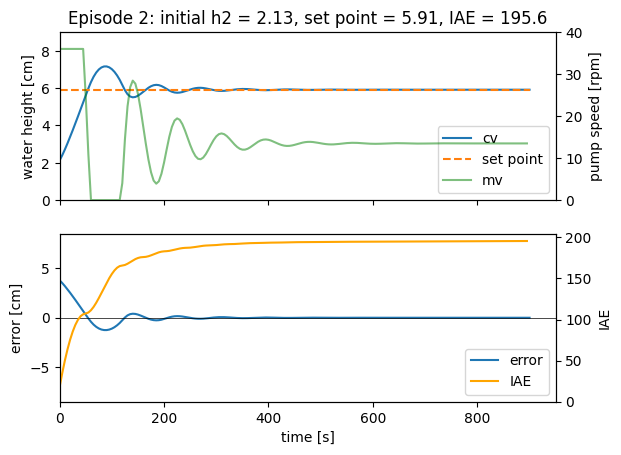

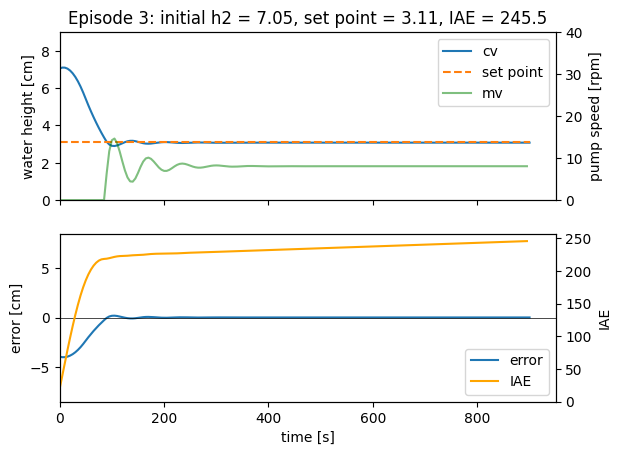

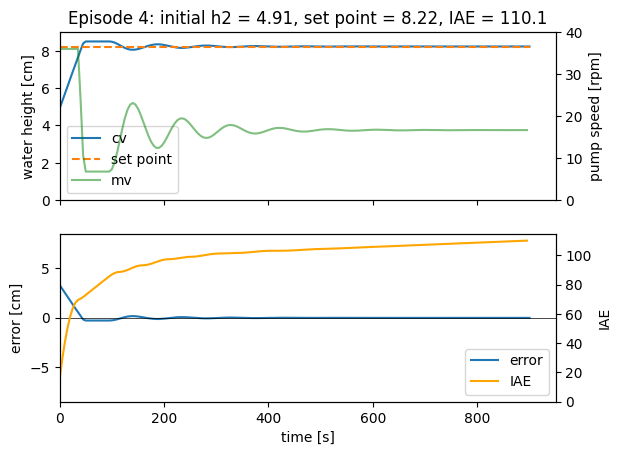

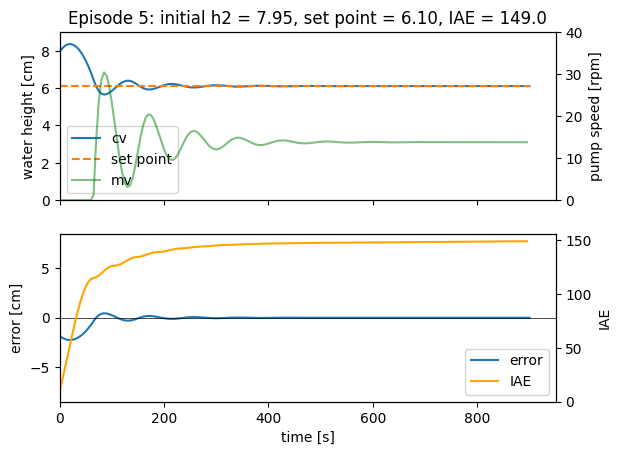

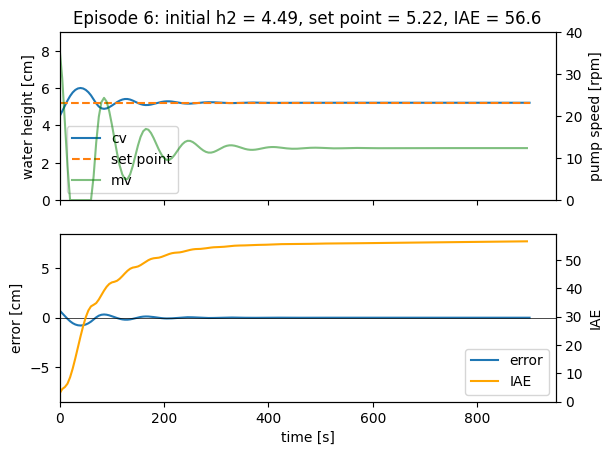

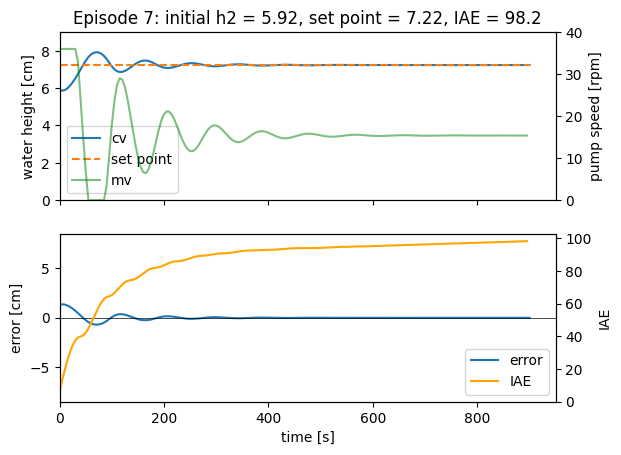

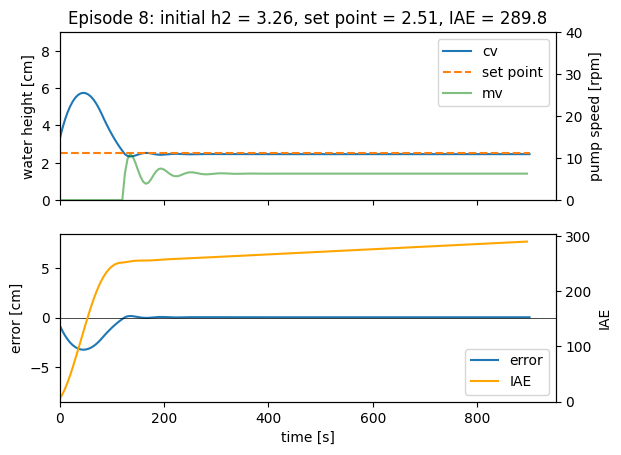

In [13]:
for i in range(2**SAMPLE_NUM):
    init_h1, init_h2, sp = sample[i]

    err = sp - init_h2
    err_traj = []
    err_traj.append(err)

    model = FirstPrincipleModel(init_h1, init_h2)
    controller = PID(kc=kc_opt,
                    P=True, I=False, D=False,
                    u_min=0, u_max=36,
                    taui=None, taud=None,
                    )
    mv = controller.final_control(sp, init_h2, DT)
    h1, h2 = model.step_pred(mv, init_h1, init_h2, DT)

    err = sp - h2
    err_traj.append(err)

    for j in range(TOT_ITER):
        mv = controller.final_control(sp, h2, DT)
        h1, h2 = model.step_pred(mv, h1, h2, DT)
        err = sp - h2
        err_traj.append(err)

    trajectories = model.outcome(h2=True, mv=True)
    
    iae = analysis(err_traj, trajectories["time"])[1]

    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)
    ax1.set_title(f"Episode {i+1}: initial h2 = {init_h2:.2f}, set point = {sp:.2f}, IAE = {iae[-1]:.1f}")
    line1 = ax1.plot(trajectories["time"], trajectories["h2"], label="cv")
    line2 = ax1.plot(trajectories["time"], sp * np.ones(len(trajectories["time"])), ls="--", label="set point")
    ax1.set_ylabel("water height [cm]")
    ax1.set_ylim((0, 9))
    ax1.set_xlim((0, 950))
    ax3 = ax1.twinx()
    line3 = ax3.plot(trajectories["time"][:-1], trajectories["mv"], label="mv", c="g", alpha=0.5)
    ax3.set_ylabel("pump speed [rpm]")
    ax3.set_ylim((0, 40))
    lines = line1 + line2 + line3
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")

    line4 = ax2.plot(trajectories["time"], err_traj, label="error")
    ax2.set_xlabel("time [s]")
    ax2.set_ylabel("error [cm]")
    ax2.set_ylim((-8.5, 8.5))
    ax2.axhline(y=0, color="k", lw=0.5)
    ax4 = ax2.twinx()
    line5 = ax4.plot(trajectories["time"][:-1], iae, c="orange",label="IAE")
    ax4.set_ylabel("IAE")
    ax4.set_ylim(bottom=0)
    lines = line4 + line5
    labels = [line.get_label() for line in lines]
    ax2.legend(lines, labels, loc="lower right")
    plt.show()
    
#    table_df = pd.DataFrame([err_traj, trajectories["time"]], index=["err_traj", "time"])
#    display(HTML(f"""<div style="overflow-x: auto; width: 100%; border: 1px solid #ccc;"> {table_df.to_html(border=1)} </div>"""))

## PI tuning

In [14]:
TAUI_MULTIPLE = 500
TAUI_MIN = 0.1

In [15]:
d = 2

sobol = SobolEngine(dimension=d, scramble=True)
train_X = sobol.draw(PRIORI_SAMPLE_SIZE).to(dtype=torch.float64)

train_Y = torch.tensor([[model_evaluation(P_MULTIPLE*x[0], taui=TAUI_MULTIPLE*x[1]+TAUI_MIN)] for x in train_X], dtype=torch.float64)

In [16]:
gp = SingleTaskGP(train_X = train_X,
                  train_Y = train_Y,
                  outcome_transform = Standardize(m=1))
mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
fit_gpytorch_mll(mll)
state_dict = gp.state_dict()
best_Y = train_Y.max().item()

In [17]:
NUM_BO_ITER = 150

best_output = []
best_output.append(best_Y)

bounds = torch.stack([torch.tensor([0, 0]), torch.tensor([1, 1])]).to(torch.double)

for i in range(NUM_BO_ITER):
    EI = qLogExpectedImprovement(model=gp, best_f=best_Y)

    candidate, acq_value = optimize_acqf(
        EI, bounds=bounds, q=1, num_restarts=10, raw_samples=64, options={"maxiter": 50}
    )
    if i%(NUM_BO_ITER/10) == 0:
        print(f"{int(i/NUM_BO_ITER*100)}%")
    candidate_Y = torch.tensor([[model_evaluation(P_MULTIPLE*candidate[0,0], taui=TAUI_MULTIPLE*candidate[0,1]+TAUI_MIN)]], dtype=torch.double)

    train_X, train_Y = torch.cat([train_X, candidate]), torch.cat([train_Y, candidate_Y])
    best_Y = train_Y.max().item()
    best_output.append(best_Y)

    gp = SingleTaskGP(train_X = train_X,
                    train_Y = train_Y,
                    outcome_transform = Standardize(m=1))
    gp.load_state_dict(state_dict, strict=False)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    state_dict = gp.state_dict()
    

0%
10%
20%
30%
40%
50%
60%
70%
80%
90%


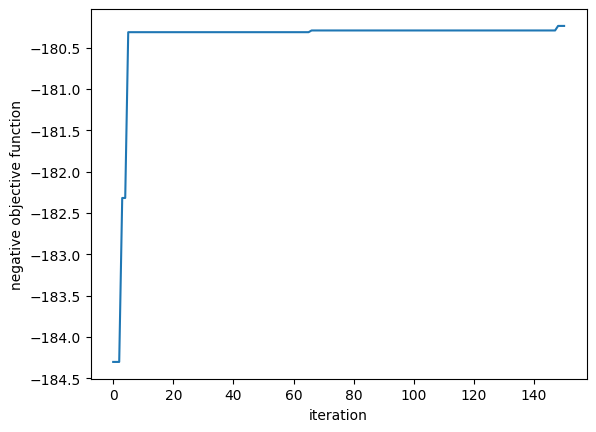

-180.23825564206965
23.7354033363494 270.21155427578026


In [18]:
plt.plot(best_output)
plt.xlabel("iteration")
plt.ylabel("negative objective function")
plt.show()

print(best_output[-1])

best_arg = torch.argmax(train_Y)
kc_opt, taui_opt = float(train_X[best_arg][0]*P_MULTIPLE), float(train_X[best_arg][1]*TAUI_MULTIPLE)
print(kc_opt, taui_opt)

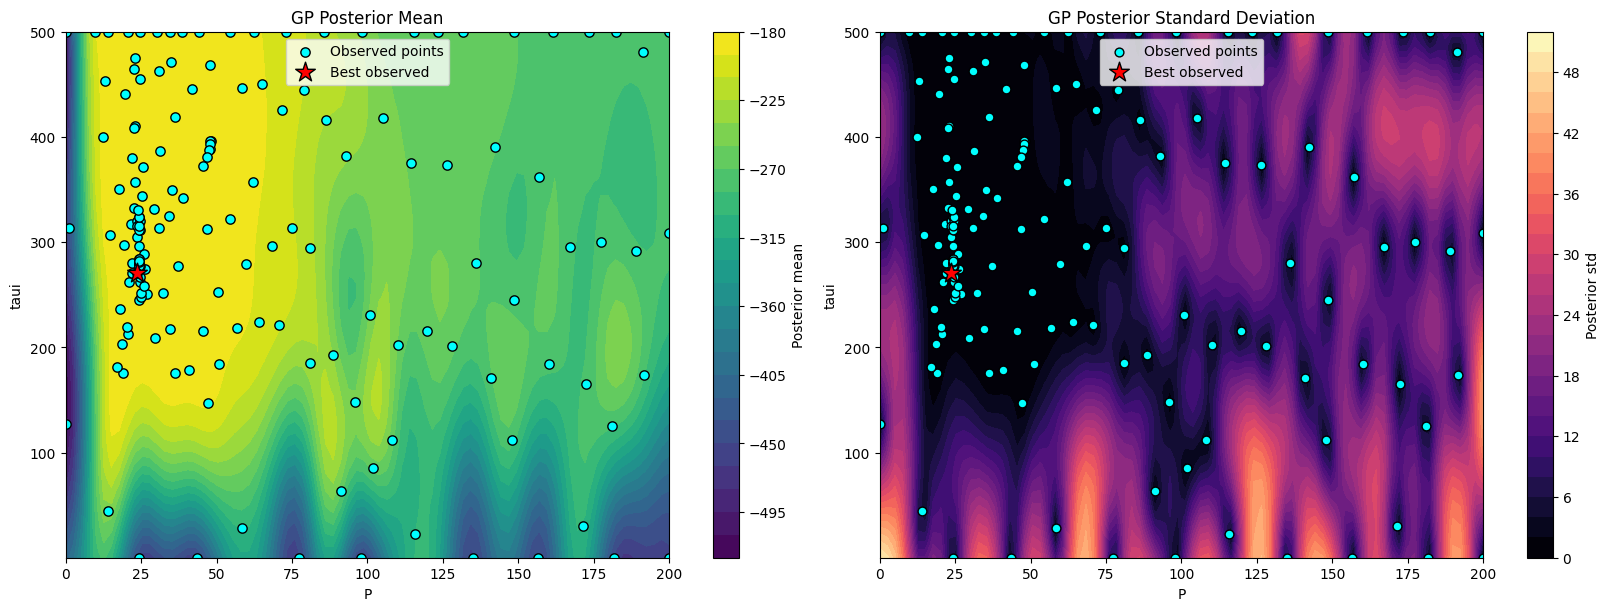

In [19]:
gp.eval()

# Make dense grid in normalized space
x1 = torch.linspace(0.0, 1.0, 80, dtype=torch.double)
x2 = torch.linspace(0.0, 1.0, 80, dtype=torch.double)
X1, X2 = torch.meshgrid(x1, x2, indexing="ij")
Xgrid = torch.stack([X1.reshape(-1), X2.reshape(-1)], dim=-1)

# GP posterior on grid
with torch.no_grad():
    posterior = gp.posterior(Xgrid)
    mean = posterior.mean.reshape(80, 80).cpu().numpy()
    std = posterior.variance.sqrt().reshape(80, 80).cpu().numpy()

# Convert normalized axes to physical units
X_plot = (X1.cpu().numpy()) * P_MULTIPLE
Y_plot = (X2.cpu().numpy()) * TAUI_MULTIPLE + TAUI_MIN

train_X_np = train_X.detach().cpu().numpy()
train_Y_np = train_Y.detach().cpu().numpy().reshape(-1)

train_X1_plot = train_X_np[:, 0] * P_MULTIPLE
train_X2_plot = train_X_np[:, 1] * TAUI_MULTIPLE + TAUI_MIN

best_idx = np.argmax(train_Y_np)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# --- Posterior mean ---
cs1 = axes[0].contourf(X_plot, Y_plot, mean, levels=30, cmap="viridis")
sc1 = axes[0].scatter(
    train_X1_plot,
    train_X2_plot,
    c="cyan",
    edgecolor="black",
    s=45,
    label="Observed points"
)
axes[0].scatter(
    train_X1_plot[best_idx],
    train_X2_plot[best_idx],
    marker="*",
    s=220,
    c="r",
    edgecolor="black",
    linewidth=1.0,
    label="Best observed"
)
axes[0].set_title("GP Posterior Mean")
axes[0].set_xlabel("P")
axes[0].set_ylabel("taui")
axes[0].legend()
fig.colorbar(cs1, ax=axes[0], label="Posterior mean")

# --- Posterior std ---
cs2 = axes[1].contourf(X_plot, Y_plot, std, levels=30, cmap="magma")
axes[1].scatter(
    train_X1_plot,
    train_X2_plot,
    c="cyan",
    edgecolor="black",
    s=40,
    label="Observed points"
)
axes[1].scatter(
    train_X1_plot[best_idx],
    train_X2_plot[best_idx],
    marker="*",
    s=220,
    c="r",
    edgecolor="black",
    linewidth=1.0,
    label="Best observed"
)
axes[1].set_title("GP Posterior Standard Deviation")
axes[1].set_xlabel("P")
axes[1].set_ylabel("taui")
axes[1].legend()
fig.colorbar(cs2, ax=axes[1], label="Posterior std")

plt.show()

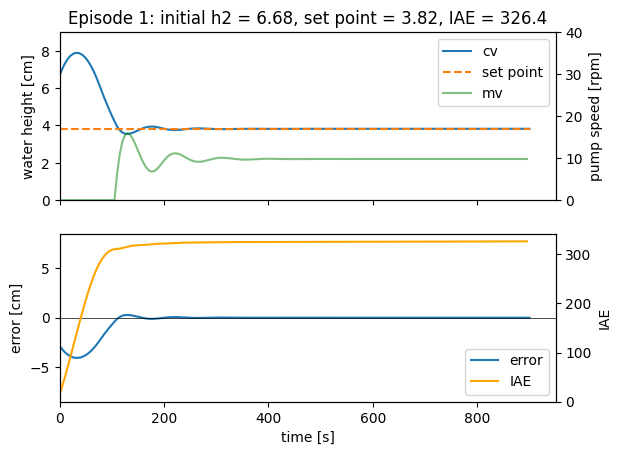

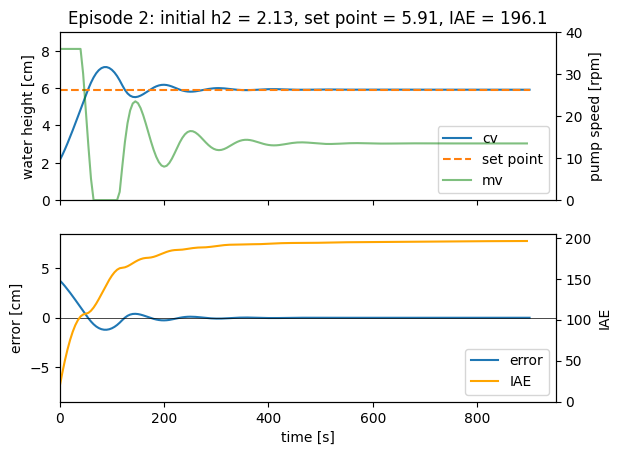

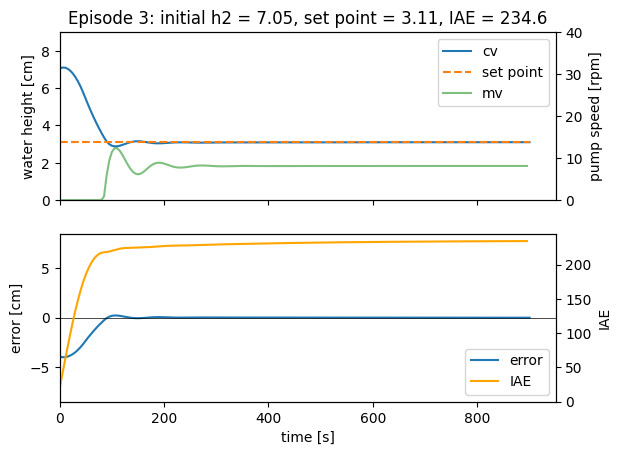

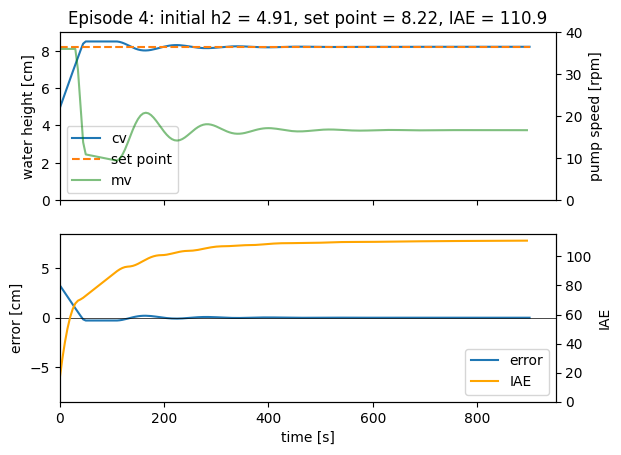

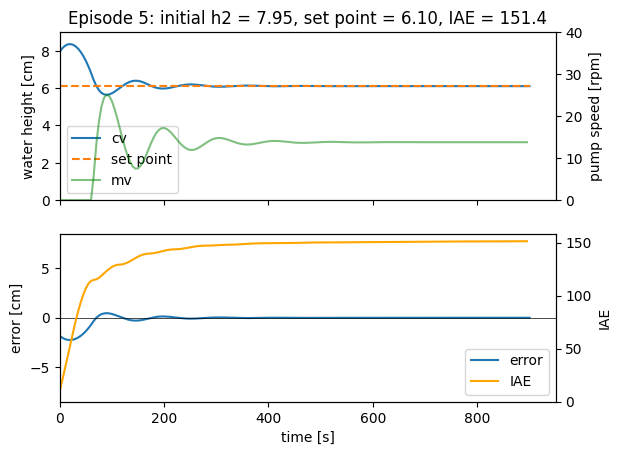

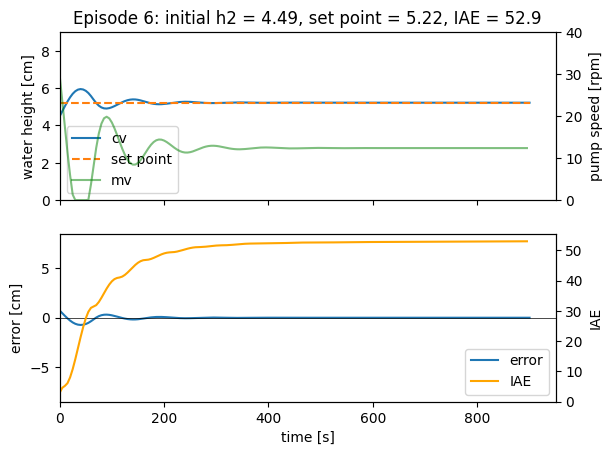

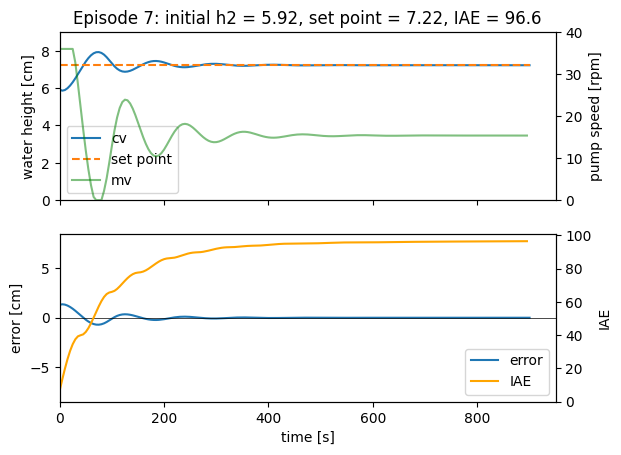

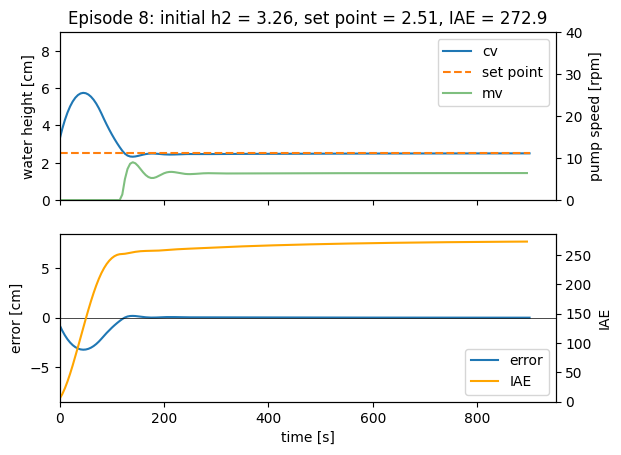

In [20]:
for i in range(2**SAMPLE_NUM):
    init_h1, init_h2, sp = sample[i]

    err = sp - init_h2
    err_traj = []
    err_traj.append(err)

    model = FirstPrincipleModel(init_h1, init_h2)
    controller = PID(kc=kc_opt,
                    P=True, I=True, D=False,
                    u_min=0, u_max=36,
                    taui=taui_opt, taud=None,
                    )
    mv = controller.final_control(sp, init_h2, DT)
    h1, h2 = model.step_pred(mv, init_h1, init_h2, DT)

    err = sp - h2
    err_traj.append(err)

    for j in range(TOT_ITER):
        mv = controller.final_control(sp, h2, DT)
        h1, h2 = model.step_pred(mv, h1, h2, DT)
        err = sp - h2
        err_traj.append(err)

    trajectories = model.outcome(h2=True, mv=True)
    
    iae = analysis(err_traj, trajectories["time"])[1]

    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)
    ax1.set_title(f"Episode {i+1}: initial h2 = {init_h2:.2f}, set point = {sp:.2f}, IAE = {iae[-1]:.1f}")
    line1 = ax1.plot(trajectories["time"], trajectories["h2"], label="cv")
    line2 = ax1.plot(trajectories["time"], sp * np.ones(len(trajectories["time"])), ls="--", label="set point")
    ax1.set_ylabel("water height [cm]")
    ax1.set_ylim((0, 9))
    ax1.set_xlim((0, 950))
    ax3 = ax1.twinx()
    line3 = ax3.plot(trajectories["time"][:-1], trajectories["mv"], label="mv", c="g", alpha=0.5)
    ax3.set_ylabel("pump speed [rpm]")
    ax3.set_ylim((0, 40))
    lines = line1 + line2 + line3
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")

    line4 = ax2.plot(trajectories["time"], err_traj, label="error")
    ax2.set_xlabel("time [s]")
    ax2.set_ylabel("error [cm]")
    ax2.set_ylim((-8.5, 8.5))
    ax2.axhline(y=0, color="k", lw=0.5)
    ax4 = ax2.twinx()
    line5 = ax4.plot(trajectories["time"][:-1], iae, c="orange",label="IAE")
    ax4.set_ylabel("IAE")
    ax4.set_ylim(bottom=0)
    lines = line4 + line5
    labels = [line.get_label() for line in lines]
    ax2.legend(lines, labels, loc="lower right")
    plt.show()
    
#    table_df = pd.DataFrame([err_traj, trajectories["time"]], index=["err_traj", "time"])
#    display(HTML(f"""<div style="overflow-x: auto; width: 100%; border: 1px solid #ccc;"> {table_df.to_html(border=1)} </div>"""))

## PID tuning

In [21]:
TAUD_MULTIPLE = 50
TAUD_MIN = 1e-4

In [22]:
d = 3

sobol = SobolEngine(dimension=d, scramble=True)
train_X = sobol.draw(PRIORI_SAMPLE_SIZE).to(dtype=torch.float64)

train_Y = torch.tensor([[model_evaluation(P_MULTIPLE*x[0], taui=TAUI_MULTIPLE*x[1]+TAUI_MIN, taud=TAUD_MULTIPLE*x[2]+TAUD_MIN)] for x in train_X], dtype=torch.float64)

In [23]:
gp = SingleTaskGP(train_X = train_X,
                  train_Y = train_Y,
                  outcome_transform = Standardize(m=1))
mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
fit_gpytorch_mll(mll)
state_dict = gp.state_dict()
best_Y = train_Y.max().item()

In [24]:
NUM_BO_ITER = 300

best_output = []
best_output.append(best_Y)

bounds = torch.stack([torch.tensor([0, 0, 0]), torch.tensor([1, 1, 1])]).to(torch.double)

for i in range(NUM_BO_ITER):
    EI = qLogExpectedImprovement(model=gp, best_f=best_Y)

    candidate, acq_value = optimize_acqf(
        EI, bounds=bounds, q=1, num_restarts=10, raw_samples=64, options={"maxiter": 50}
    )
    if i%(NUM_BO_ITER/10) == 0:
        print(f"{int(i/NUM_BO_ITER*100)}%")
    candidate_Y = torch.tensor([[model_evaluation(P_MULTIPLE*candidate[0,0], taui=TAUI_MULTIPLE*candidate[0,1]+TAUI_MIN, taud=TAUD_MULTIPLE*candidate[0,2]+TAUD_MIN)]], dtype=torch.double)

    train_X, train_Y = torch.cat([train_X, candidate]), torch.cat([train_Y, candidate_Y])
    best_Y = train_Y.max().item()
    best_output.append(best_Y)

    gp = SingleTaskGP(train_X = train_X,
                    train_Y = train_Y,
                    outcome_transform = Standardize(m=1))
    gp.load_state_dict(state_dict, strict=False)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)
    state_dict = gp.state_dict()

0%
10%
20%
30%
40%
50%
60%
70%
80%
90%


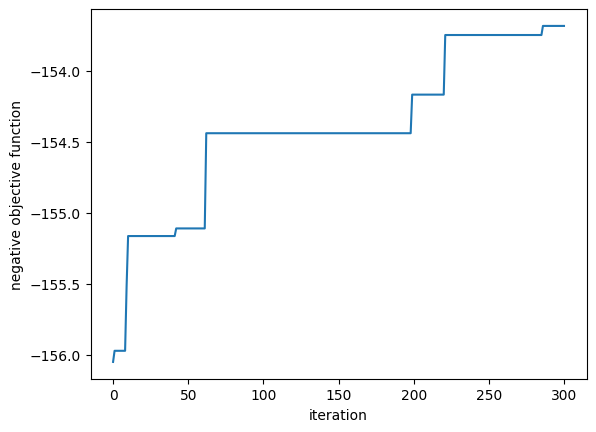

-153.68142625412042
83.15558507920643 159.94643719000047 8.347486543933783


In [25]:
plt.plot(best_output)
plt.xlabel("iteration")
plt.ylabel("negative objective function")
plt.show()

print(best_output[-1])

best_arg = torch.argmax(train_Y)
kc_opt, taui_opt, taud_opt = float(train_X[best_arg][0]*P_MULTIPLE), float(train_X[best_arg][1]*TAUI_MULTIPLE + TAUI_MIN), float(train_X[best_arg][2]*TAUD_MULTIPLE + TAUD_MIN)
print(kc_opt, taui_opt, taud_opt)

In [26]:
from torch.quasirandom import SobolEngine


def posterior_mean_batched(model, X, batch_size=4096):
    model.eval()
    outs = []
    with torch.no_grad():
        for Xb in X.split(batch_size):
            outs.append(model.posterior(Xb).mean.squeeze(-1).cpu())
    return torch.cat(outs, dim=0)


def partial_dependence_2d(
    model,
    dim_x,
    dim_y,
    d=3,
    n_grid=50,
    n_samples=128,
    dtype=torch.double,
    device="cpu",
    batch_size=4096,
):
    """
    Returns skopt-style 2D partial dependence for dimensions (dim_x, dim_y)
    by averaging over the remaining dimension(s).
    Input space is assumed normalized to [0,1]^d.
    """
    # grid for the two shown dimensions
    gx = torch.linspace(0.0, 1.0, n_grid, dtype=dtype, device=device)
    gy = torch.linspace(0.0, 1.0, n_grid, dtype=dtype, device=device)

    # samples used to average over hidden dimension(s)
    sobol = SobolEngine(dimension=d, scramble=True)
    base_samples = sobol.draw(n_samples).to(dtype=dtype, device=device)

    Z = np.zeros((n_grid, n_grid))

    for iy, yv in enumerate(gy):
        row_blocks = []
        for xv in gx:
            X = base_samples.clone()
            X[:, dim_x] = xv
            X[:, dim_y] = yv
            row_blocks.append(X)

        # shape: (n_grid * n_samples, d)
        Xquery = torch.cat(row_blocks, dim=0)

        mu = posterior_mean_batched(model, Xquery, batch_size=batch_size)
        # reshape so each x-grid point has n_samples hidden-dim samples
        mu = mu.reshape(n_grid, n_samples).mean(dim=1)

        Z[iy, :] = mu.numpy()

    return gx.cpu().numpy(), gy.cpu().numpy(), Z

def partial_dependence_1d(
    model,
    dim,
    d=3,
    n_grid=100,
    n_samples=256,
    dtype=torch.double,
    device="cpu",
    batch_size=4096,
):
    """
    Compute 1D partial dependence for one variable in normalized space [0,1]^d.

    Parameters
    ----------
    model : fitted BoTorch GP model
    dim : int
        Index of variable to plot
    d : int
        Input dimension
    n_grid : int
        Number of grid points for the plotted variable
    n_samples : int
        Number of Sobol samples used to average over remaining variables
    dtype, device : torch dtype/device
    batch_size : int
        Batch size for posterior evaluation

    Returns
    -------
    g : numpy array of shape (n_grid,)
        Grid in normalized space [0,1]
    pd : numpy array of shape (n_grid,)
        Partial dependence values
    """
    g = torch.linspace(0.0, 1.0, n_grid, dtype=dtype, device=device)

    # Sample full d-dimensional points, then overwrite plotted dim
    sobol = SobolEngine(dimension=d, scramble=True)
    base_samples = sobol.draw(n_samples).to(dtype=dtype, device=device)

    blocks = []
    for xv in g:
        X = base_samples.clone()
        X[:, dim] = xv
        blocks.append(X)

    # (n_grid * n_samples, d)
    Xquery = torch.cat(blocks, dim=0)

    mu = posterior_mean_batched(model, Xquery, batch_size=batch_size)

    # reshape to (n_grid, n_samples), then average over hidden dimensions
    pd = mu.reshape(n_grid, n_samples).mean(dim=1)

    return g.cpu().numpy(), pd.numpy()

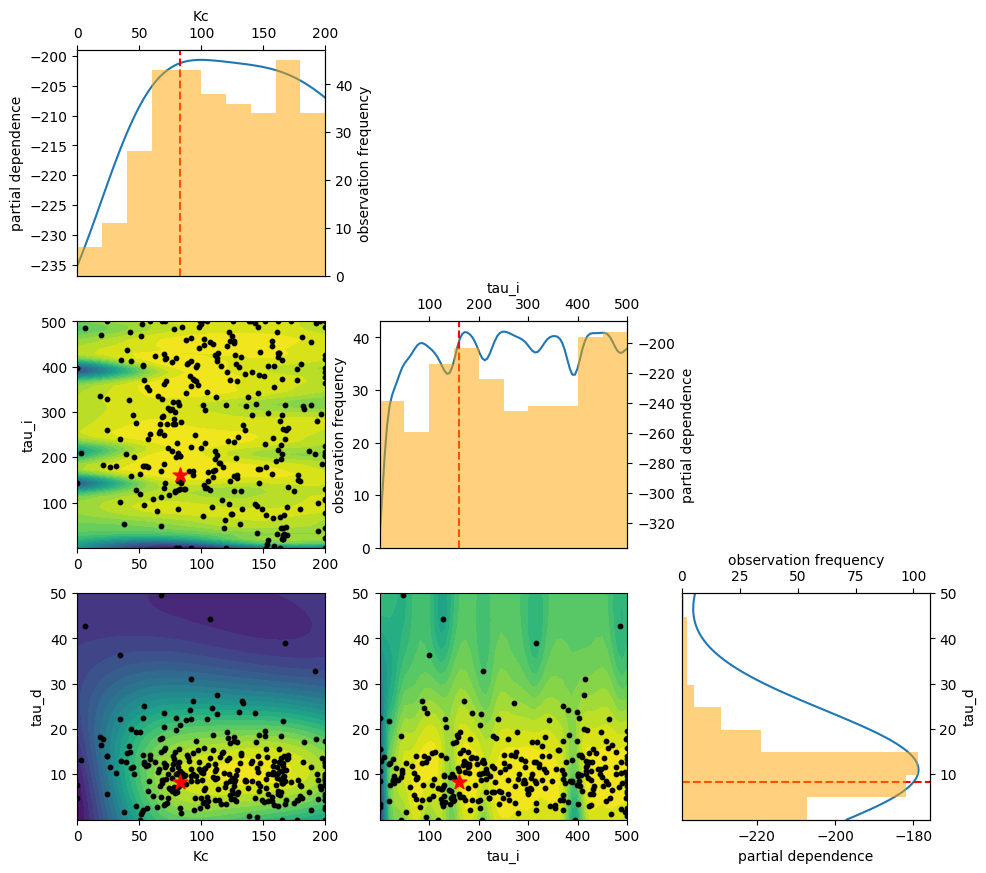

In [29]:
gp.eval()

GRID_DISCRETIZATTION = 40

fig, ((ax1, ax2, ax3),
      (ax4, ax5, ax6),
      (ax7, ax8, ax9)) = plt.subplots(nrows=3, ncols=3, figsize=(11, 10))
fig.subplots_adjust(wspace=0.22, hspace=0.20)

# kx(x) partial dependence at ax1
g, pd = partial_dependence_1d(
    model=gp,
    dim=0,
    d=3,
    n_grid=100,
    n_samples=256,
    dtype=train_X.dtype,
    device=train_X.device,
)

x_plot = g * P_MULTIPLE

ax1.plot(x_plot, pd, color="C0")
ax1.axvline(
    float(train_X[best_arg, 0] * P_MULTIPLE),
    color="red",
    linestyle="--"
)
ax1.set_ylabel("partial dependence")
ax1.xaxis.set_label_position("top")
ax1.xaxis.tick_top()
ax1.set_xlabel("Kc")
ax1.set_xlim((0, P_MULTIPLE))

# ax2 off
ax2.axis("off")

# ax3 off
ax3.axis("off")

# kc(x), taui(y) contour at ax4
gx, gy, Z = partial_dependence_2d(
    model=gp,
    dim_x=0,
    dim_y=1,
    d=3,
    n_grid=50,
    n_samples=128,
    dtype=train_X.dtype,
    device=train_X.device,
)

X_plot, Y_plot = np.meshgrid(
    gx * P_MULTIPLE,
    gy * TAUI_MULTIPLE + TAUI_MIN,
    indexing="xy"
)

ax4.contourf(X_plot, Y_plot, Z, levels=25, cmap="viridis")
ax4.scatter(
    train_X[:, 0].cpu().numpy() * P_MULTIPLE,
    train_X[:, 1].cpu().numpy() * TAUI_MULTIPLE + TAUI_MIN,
    c="k", s=10
)
ax4.scatter(
    float(train_X[best_arg, 0] * P_MULTIPLE),
    float(train_X[best_arg, 1] * TAUI_MULTIPLE + TAUI_MIN),
    c="red", marker="*", s=120
)
ax4.set_ylabel("tau_i")
ax4.set_ylim((TAUI_MIN, TAUI_MULTIPLE + TAUI_MIN))
ax4.set_xlim((0, P_MULTIPLE))
ax4.xaxis.set_major_locator(MultipleLocator(50))

# taui(x) partial dependence at ax5
g, pd = partial_dependence_1d(
    model=gp,
    dim=1,
    d=3,
    n_grid=100,
    n_samples=256,
    dtype=train_X.dtype,
    device=train_X.device,
)

x_plot = g * TAUI_MULTIPLE + TAUI_MIN

ax5.plot(x_plot, pd, color="C0")
ax5.axvline(
    float(train_X[best_arg, 1] * TAUI_MULTIPLE + TAUI_MIN),
    color="red",
    linestyle="--"
)
ax5.xaxis.set_label_position("top")
ax5.xaxis.tick_top()
ax5.set_xlabel("tau_i")
ax5.set_xlim((TAUI_MIN, TAUI_MULTIPLE + TAUI_MIN))
ax5.xaxis.set_major_locator(MultipleLocator(100))

# ax6 off
ax6.axis("off")

# kc(x), taud(y) contour at ax7
gx, gy, Z = partial_dependence_2d(
    model=gp,
    dim_x=0,
    dim_y=2,
    d=3,
    n_grid=50,
    n_samples=128,
    dtype=train_X.dtype,
    device=train_X.device,
)

X_plot, Y_plot = np.meshgrid(
    gx * P_MULTIPLE,
    gy * TAUD_MULTIPLE + TAUD_MIN,
    indexing="xy"
)

ax7.contourf(X_plot, Y_plot, Z, levels=25, cmap="viridis")
ax7.scatter(
    train_X[:, 0].cpu().numpy() * P_MULTIPLE,
    train_X[:, 2].cpu().numpy() * TAUD_MULTIPLE + TAUD_MIN,
    c="k", s=10
)
ax7.scatter(
    float(train_X[best_arg, 0] * P_MULTIPLE),
    float(train_X[best_arg, 2] * TAUD_MULTIPLE + TAUD_MIN),
    c="red", marker="*", s=120
)
ax7.set_xlabel("Kc")
ax7.set_xlim((0, P_MULTIPLE))
ax7.set_ylabel("tau_d")
ax7.set_ylim((TAUD_MIN, TAUD_MULTIPLE+TAUD_MIN))

# taui(x), taud(y) contour at ax8
gx, gy, Z = partial_dependence_2d(
    model=gp,
    dim_x=1,
    dim_y=2,
    d=3,
    n_grid=50,
    n_samples=128,
    dtype=train_X.dtype,
    device=train_X.device,
)

X_plot, Y_plot = np.meshgrid(
    gx * TAUI_MULTIPLE + TAUI_MIN,
    gy * TAUD_MULTIPLE + TAUD_MIN,
    indexing="xy"
)

ax8.contourf(X_plot, Y_plot, Z, levels=25, cmap="viridis")
ax8.scatter(
    train_X[:, 1].cpu().numpy() * TAUI_MULTIPLE + TAUI_MIN,
    train_X[:, 2].cpu().numpy() * TAUD_MULTIPLE + TAUD_MIN,
    c="k", s=10
)
ax8.scatter(
    float(train_X[best_arg, 1] * TAUI_MULTIPLE + TAUI_MIN),
    float(train_X[best_arg, 2] * TAUD_MULTIPLE + TAUD_MIN),
    c="red", marker="*", s=120
)
ax8.set_xlabel("tau_i")
ax8.set_xlim((TAUI_MIN, TAUI_MULTIPLE + TAUI_MIN))
ax8.set_ylim((TAUD_MIN, TAUD_MULTIPLE+TAUD_MIN))
ax8.xaxis.set_major_locator(MultipleLocator(100))

# taud(y) partial dependence at ax9
g, pd = partial_dependence_1d(
    model=gp,
    dim=2,
    d=3,
    n_grid=100,
    n_samples=256,
    dtype=train_X.dtype,
    device=train_X.device,
)

x_plot = g * TAUD_MULTIPLE + TAUD_MIN

ax9.plot(pd, x_plot, color="C0")
ax9.axhline(
    float(train_X[best_arg, 2] * TAUD_MULTIPLE + TAUD_MIN),
    color="red",
    linestyle="--"
)
ax9.set_xlabel("partial dependence")
ax9.set_ylabel("tau_d")
ax9.set_ylim((TAUD_MIN, TAUD_MULTIPLE+TAUD_MIN))
ax9.yaxis.set_label_position("right")
ax9.yaxis.tick_right()

kc_obs = train_X[:, 0].cpu().numpy() * P_MULTIPLE
taui_obs = train_X[:, 1].cpu().numpy() * TAUI_MULTIPLE + TAUI_MIN
taud_obs = train_X[:, 2].cpu().numpy() * TAUD_MULTIPLE + TAUD_MIN

bins = 10
alpha = 0.5
ax10 = ax1.twinx()
ax10.hist(kc_obs, bins=bins, color="orange", alpha=alpha)
ax10.set_ylabel("observation frequency")

ax11 = ax5.twinx()
ax11.hist(taui_obs, bins=bins, color="orange", alpha=alpha)
ax11.set_ylabel("observation frequency")

ax12 = ax9.twiny()
ax12.hist(taud_obs, bins=bins, color="orange", alpha=alpha, orientation="horizontal")
ax12.xaxis.set_label_position("top")
ax12.xaxis.tick_top()
ax12.set_xlabel("observation frequency")

# partial dependence axis on the RIGHT
ax5.set_ylabel("partial dependence")
ax5.yaxis.set_label_position("right")
ax5.yaxis.set_ticks_position("right")
ax5.tick_params(axis="y", right=True, labelright=True, left=False, labelleft=False)

# histogram axis on the LEFT
ax11.yaxis.set_label_position("left")
ax11.yaxis.set_ticks_position("left")
ax11.tick_params(axis="y", left=True, labelleft=True, right=False, labelright=False)

plt.show()

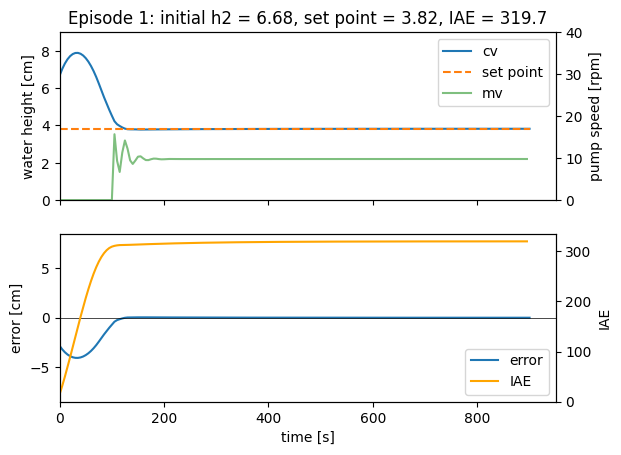

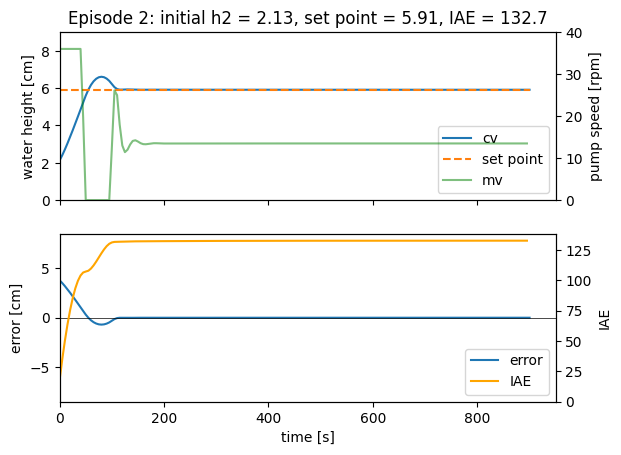

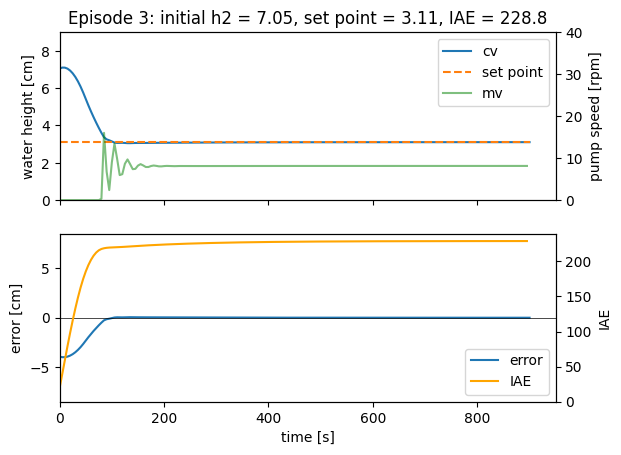

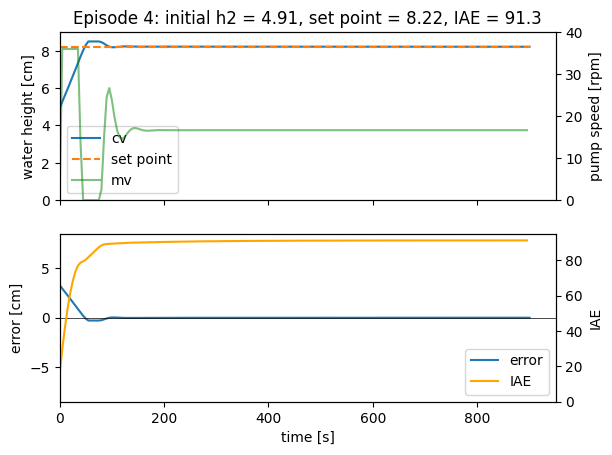

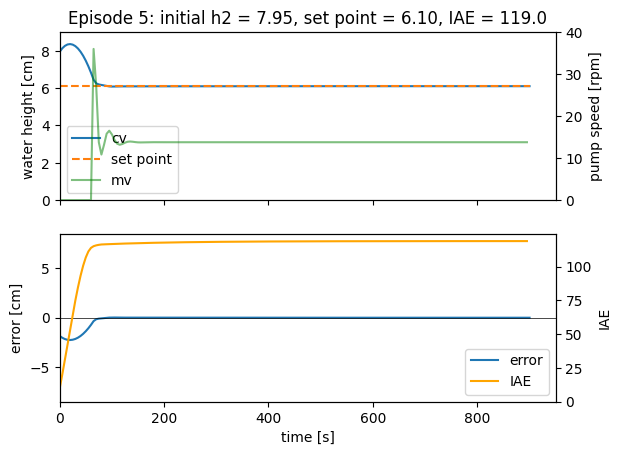

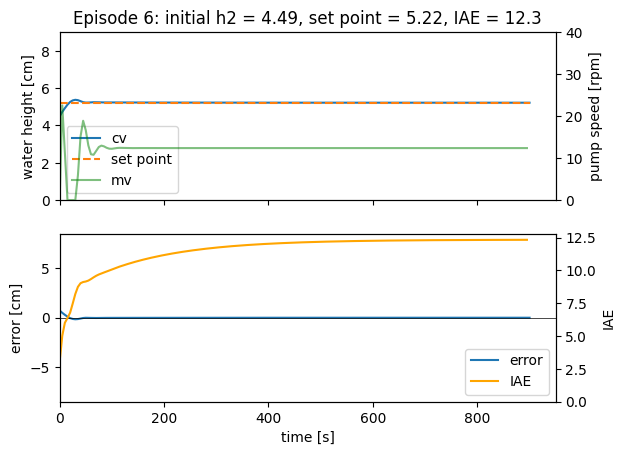

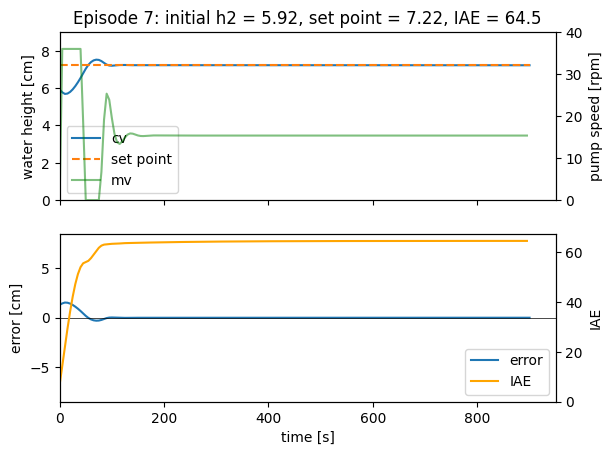

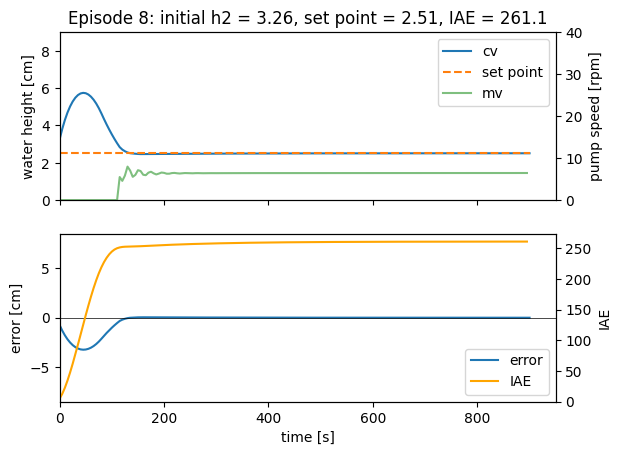

In [28]:
for i in range(2**SAMPLE_NUM):
    init_h1, init_h2, sp = sample[i]

    err = sp - init_h2
    err_traj = []
    err_traj.append(err)

    model = FirstPrincipleModel(init_h1, init_h2)
    controller = PID(kc=kc_opt,
                    P=True, I=True, D=True,
                    u_min=0, u_max=36,
                    taui=taui_opt, taud=taud_opt,
                    )
    mv = controller.final_control(sp, init_h2, DT)
    h1, h2 = model.step_pred(mv, init_h1, init_h2, DT)

    err = sp - h2
    err_traj.append(err)

    for j in range(TOT_ITER):
        mv = controller.final_control(sp, h2, DT)
        h1, h2 = model.step_pred(mv, h1, h2, DT)
        err = sp - h2
        err_traj.append(err)

    trajectories = model.outcome(h2=True, mv=True)
    
    iae = analysis(err_traj, trajectories["time"])[1]

    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)
    ax1.set_title(f"Episode {i+1}: initial h2 = {init_h2:.2f}, set point = {sp:.2f}, IAE = {iae[-1]:.1f}")
    line1 = ax1.plot(trajectories["time"], trajectories["h2"], label="cv")
    line2 = ax1.plot(trajectories["time"], sp * np.ones(len(trajectories["time"])), ls="--", label="set point")
    ax1.set_ylabel("water height [cm]")
    ax1.set_ylim((0, 9))
    ax1.set_xlim((0, 950))
    ax3 = ax1.twinx()
    line3 = ax3.plot(trajectories["time"][:-1], trajectories["mv"], label="mv", c="g", alpha=0.5)
    ax3.set_ylabel("pump speed [rpm]")
    ax3.set_ylim((0, 40))
    lines = line1 + line2 + line3
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")

    line4 = ax2.plot(trajectories["time"], err_traj, label="error")
    ax2.set_xlabel("time [s]")
    ax2.set_ylabel("error [cm]")
    ax2.set_ylim((-8.5, 8.5))
    ax2.axhline(y=0, color="k", lw=0.5)
    ax4 = ax2.twinx()
    line5 = ax4.plot(trajectories["time"][:-1], iae, c="orange",label="IAE")
    ax4.set_ylabel("IAE")
    ax4.set_ylim(bottom=0)
    lines = line4 + line5
    labels = [line.get_label() for line in lines]
    ax2.legend(lines, labels, loc="lower right")
    plt.show()
    
#    table_df = pd.DataFrame([err_traj, trajectories["time"]], index=["err_traj", "time"])
#    display(HTML(f"""<div style="overflow-x: auto; width: 100%; border: 1px solid #ccc;"> {table_df.to_html(border=1)} </div>"""))